In [1]:
import torch
import torch.nn as nn
import numpy as np
import joblib
import os
import sys
import matplotlib.pyplot as plt

In [2]:
common_dir_name = 'commons' 
common_dir_path = os.path.join(os.path.dirname(os.getcwd()), common_dir_name)
if common_dir_path not in sys.path:
    sys.path.append(common_dir_path)

In [3]:
from utils_chkpt import load_checkpoint
from nn_model_block_plausible import BlockPlausibleHNN
from utils_orbit import scipy_predict_qp_model_orbits
from utils_orbit import ground_truth_orbits
from utils_energy import calculate_gt_hamiltonian
from utils_energy import calculate_nn_hamiltonian
from utils_plot import get_global_limits
from utils_plot import eval_on_test_set

In [4]:
torch.set_default_dtype(torch.float64)
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cpu'

In [5]:
import gc
gc.collect()

0

In [ ]:
EPOC = 36
EPOCS = 60

LAYERS = 4
FAC = 7

BATCH_SZ = 200

OPTION = "att"
MODEL_PREFIX = f"opt-{OPTION}-"
MODEL_NAME=f"{MODEL_PREFIX}blk-p-hnn({LAYERS})({FAC})-bs{BATCH_SZ}"
MODEL_DIR="./checkpoints/multi-scale-v2"

LR_INIT = 1e-4
MIN_LR = 1e-6
PATIENCE = 3

PLOT_ROOT_DIR="./figures"

EVAL_PLOT_DIR=f"{PLOT_ROOT_DIR}/eval"
EVAL_FIG_DIR=f"{EVAL_PLOT_DIR}/multi-scale-v2"
if not os.path.exists(EVAL_FIG_DIR):
    os.makedirs(EVAL_FIG_DIR, exist_ok=True)

FIT_PLOT_DIR=f"{PLOT_ROOT_DIR}/fit"
FIT_FIG_DIR=f"{FIT_PLOT_DIR}/multi-scale-v2"
if not os.path.exists(FIT_FIG_DIR):
    os.makedirs(FIT_FIG_DIR, exist_ok=True)

PREFIX="scipy_"
POSTFIX=f"_lr_{LR_INIT:.0e}_pat_{PATIENCE}"


In [7]:
extend_time_window_upto_400Y = True
extend_time_window_upto_300Y = True
extend_time_window_upto_200Y = True
extend_time_window_upto_100Y = True

if extend_time_window_upto_400Y:
    extend_time_window_upto_100Y = True
    extend_time_window_upto_200Y = True
    extend_time_window_upto_300Y = True
if extend_time_window_upto_300Y:
    extend_time_window_upto_100Y = True
    extend_time_window_upto_200Y = True
if extend_time_window_upto_200Y:
    extend_time_window_upto_100Y = True

IMG_SAVE = False # True

In [8]:
stats = joblib.load(f'{MODEL_DIR}/ds_mlt_scalev.pkl')
q_max = stats['q_max']
p_max = stats['p_max']
dq_max = stats['dq_max']
dp_max = stats['dp_max']
print('Loaded q_max:', q_max)
print('Loaded p_max:', p_max)
print('Loaded dq_max:', dq_max)
print('Loaded dp_max:', dp_max)

Loaded q_max: [1.02582922e-02 1.02582922e-02 1.02582922e-02 4.76519763e-01
 4.76519763e-01 4.76519763e-01 7.37399886e-01 7.37399886e-01
 7.37399886e-01 1.02736745e+00 1.02736745e+00 1.02736745e+00
 1.68042864e+00 1.68042864e+00 1.68042864e+00 5.48445722e+00
 5.48445722e+00 5.48445722e+00 1.00744474e+01 1.00744474e+01
 1.00744474e+01 2.01200978e+01 2.01200978e+01 2.01200978e+01
 3.03539269e+01 3.03539269e+01 3.03539269e+01 4.94252788e+01
 4.94252788e+01 4.94252788e+01]
Loaded p_max: [3.49033911e-03 3.49033911e-03 3.49033911e-03 2.06830100e-06
 2.06830100e-06 2.06830100e-06 1.82197429e-05 1.82197429e-05
 1.82197429e-05 1.92060847e-05 1.92060847e-05 1.92060847e-05
 1.81176919e-06 1.81176919e-06 1.81176919e-06 2.77665838e-03
 2.77665838e-03 2.77665838e-03 6.14944299e-04 6.14944299e-04
 6.14944299e-04 6.57900453e-05 6.57900453e-05 6.57900453e-05
 5.96155624e-05 5.96155624e-05 5.96155624e-05 8.45747268e-09
 8.45747268e-09 8.45747268e-09]
Loaded dq_max: [3.49033911e-03 3.49033911e-03 3.490339

In [9]:
weight_filename = f"{MODEL_NAME}_ep_{EPOC}_of_{EPOCS}{POSTFIX}"
weight_filepath = f"{MODEL_DIR}/" + weight_filename + '.pth'

print('weight_file_path":', weight_filepath)


model = BlockPlausibleHNN(n_bodies=10, dims=3, m=FAC, n_layers=LAYERS, option="attention")
model.double()
model.to(device)

load_checkpoint(model, optimizer=None, file_path=weight_filepath) 

dt = 0.01 # 1 year = 100 steps

weight_file_path": ./checkpoints/multi-scale-v2/opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.pth
🚀 Loaded checkpoint from './checkpoints/multi-scale-v2/opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.pth' (Epoch 36)


In [10]:
print(model)

BlockPlausibleHNN(
  (v_mlp): Sequential(
    (0): PairWiseInputLinearAdaptor()
    (1): EvenActivation()
    (2): PairWiseHiddenBlockLinear()
    (3): EvenActivation()
    (4): PairWiseHiddenBlockLinear()
    (5): EvenActivation()
    (6): PairWiseLastLayer()
  )
)


In [11]:
print(f"T-net weight vector: {model.w}")

T-net weight vector: Parameter containing:
tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000], requires_grad=True)


In [12]:
print(f"V-net last weight vector: {model.w_v}")

V-net last weight vector: Parameter containing:
tensor([1.3039, 1.4341, 1.3860, 1.3607, 1.4163, 1.3421, 1.3419, 1.3418, 1.3685,
        1.1590, 1.2567, 1.2189, 1.2071, 1.2533, 1.1887, 1.2243, 1.3088, 1.3232,
        1.2420, 1.2051, 1.2431, 1.2524, 1.1780, 1.2566, 1.2831, 1.2334, 1.2040,
        1.2714, 1.2427, 1.2998, 1.1504, 1.1487, 1.2904, 1.2020, 1.2341, 1.2934,
        1.2336, 1.3348, 1.2343, 1.2174, 1.2189, 1.2326, 1.2428, 1.2620, 1.1919],
       requires_grad=True)


In [13]:
target_path = os.path.join(os.path.dirname(os.getcwd()), 'data_ode')

if target_path not in sys.path:
    sys.path.append(target_path)
pos_path = f"{target_path}/q_lite.npz"
mom_path = f"{target_path}/p_lite.npz"
dpos_path = f"{target_path}/dq_lite.npz"
dmom_path = f"{target_path}/dp_lite.npz"

plt_pars = get_global_limits(pos_path)

In [14]:
q_path = f"{target_path}/q_lite.npz"
p_path = f"{target_path}/p_lite.npz"

i: 0, interval=[0 : 50]
x0: (1, 60)
part1-scipy_eval_[0 : 50]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


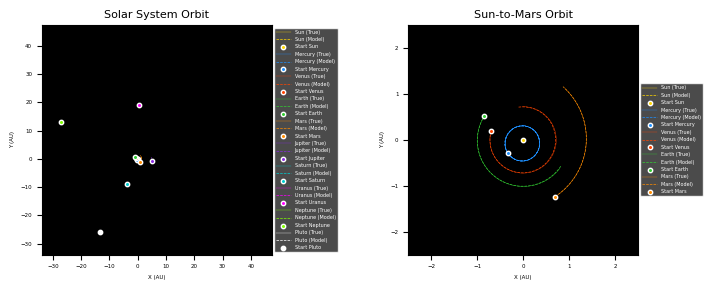

part1-scipy_metric_[0 : 50]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


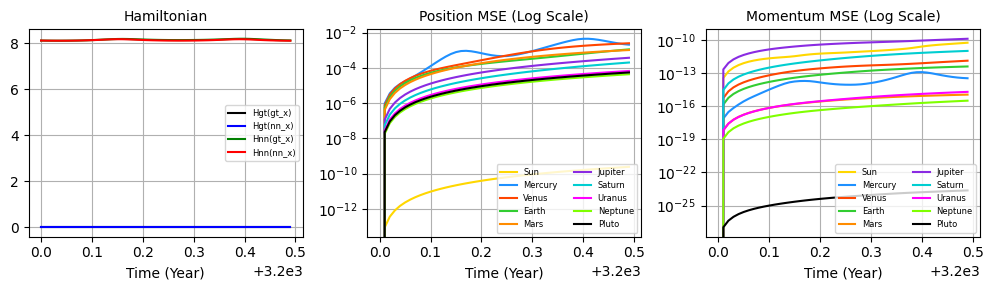

i: 1, interval=[0 : 100]
x0: (1, 60)
part1-scipy_eval_[0 : 100]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


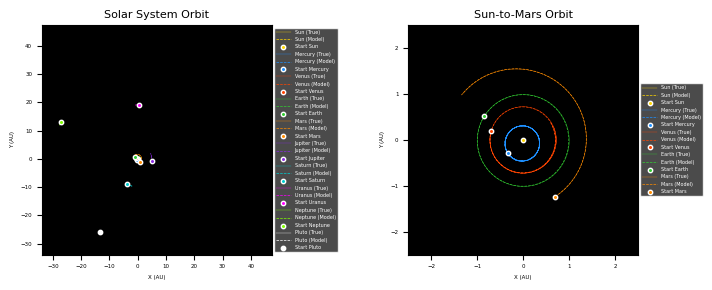

part1-scipy_metric_[0 : 100]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


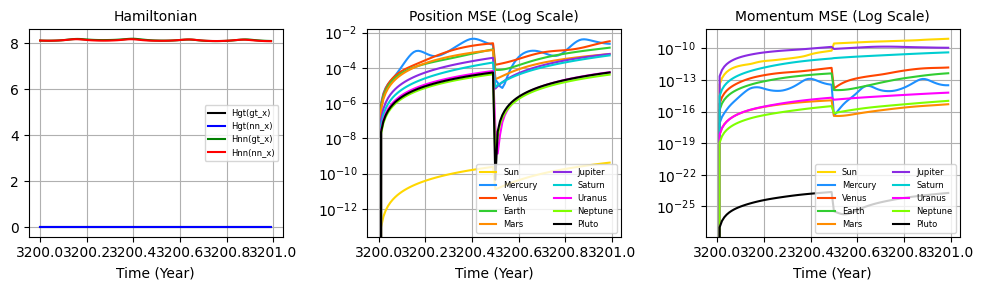

i: 2, interval=[0 : 200]
x0: (1, 60)
part1-scipy_eval_[0 : 200]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


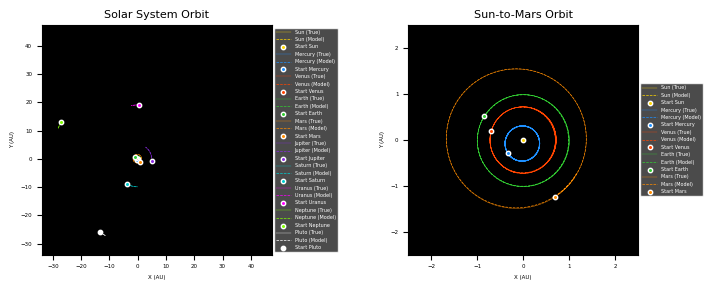

part1-scipy_metric_[0 : 200]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


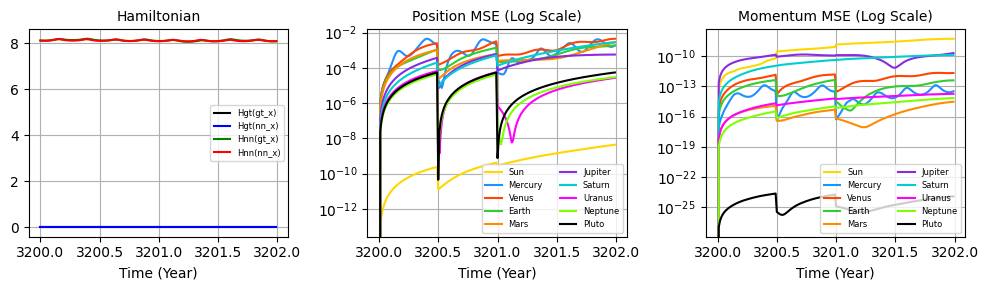

i: 3, interval=[0 : 300]
x0: (1, 60)
part1-scipy_eval_[0 : 300]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


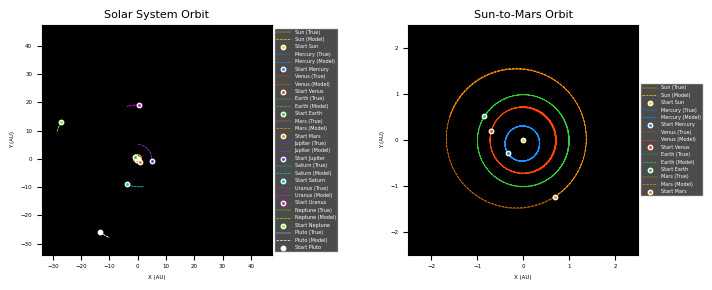

part1-scipy_metric_[0 : 300]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


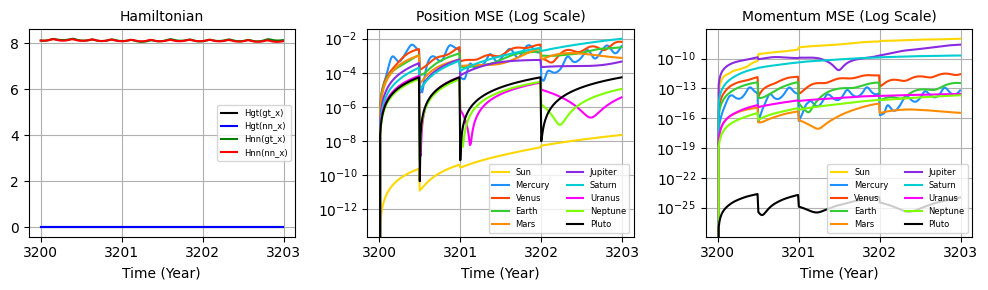

i: 4, interval=[0 : 400]
x0: (1, 60)
part1-scipy_eval_[0 : 400]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


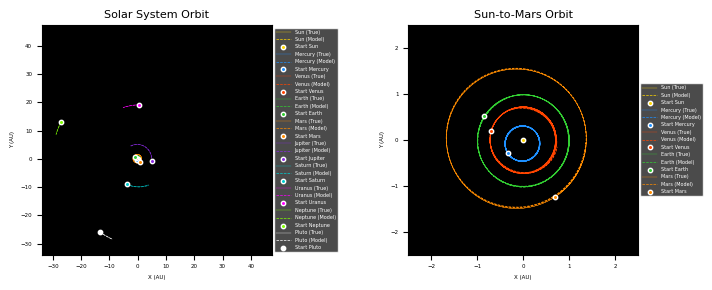

part1-scipy_metric_[0 : 400]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


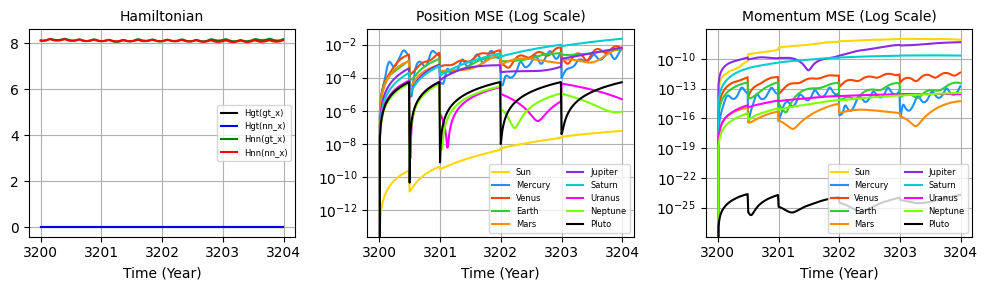

i: 5, interval=[0 : 500]
x0: (1, 60)
part1-scipy_eval_[0 : 500]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


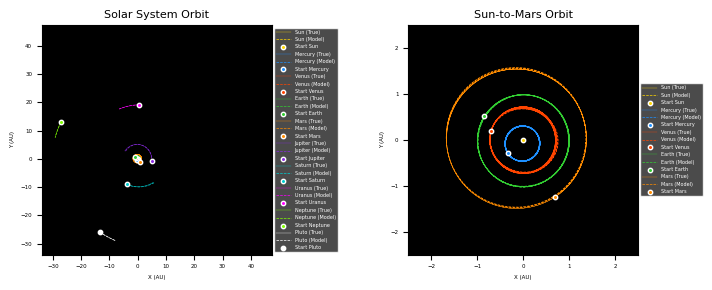

part1-scipy_metric_[0 : 500]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


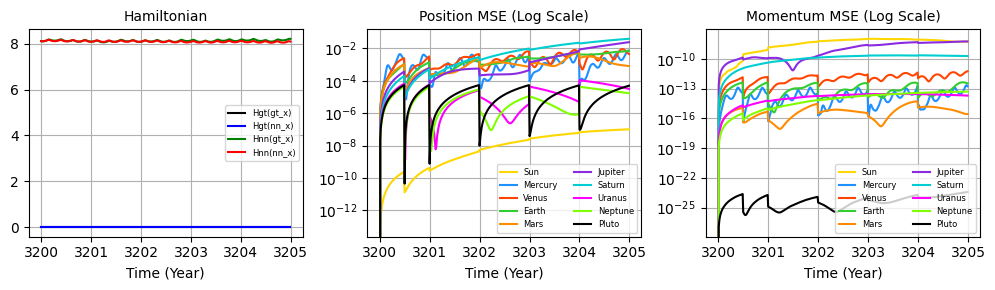

i: 6, interval=[0 : 1000]
x0: (1, 60)
part1-scipy_eval_[0 : 1000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


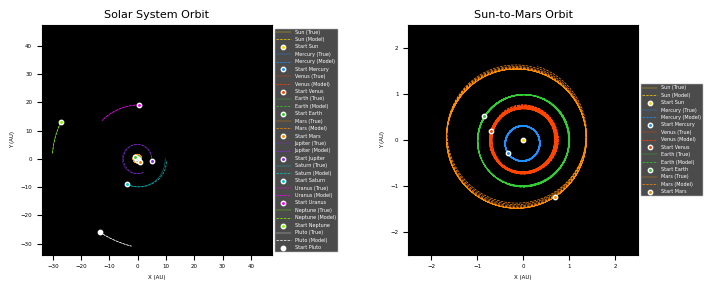

part1-scipy_metric_[0 : 1000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


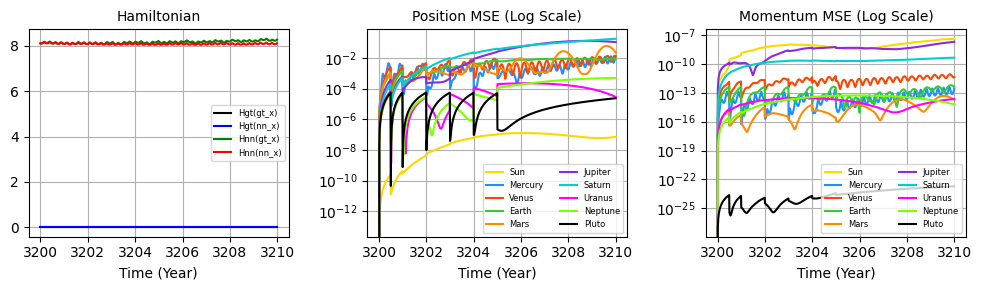

i: 7, interval=[0 : 1500]
x0: (1, 60)
part1-scipy_eval_[0 : 1500]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


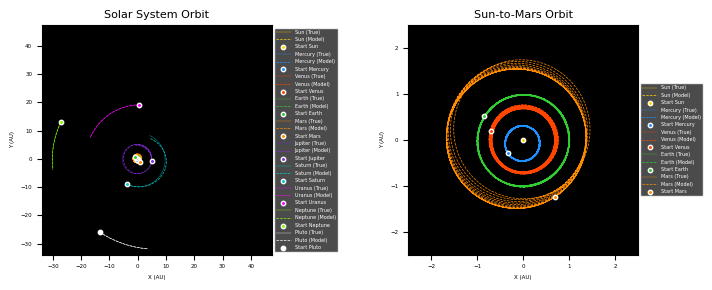

part1-scipy_metric_[0 : 1500]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


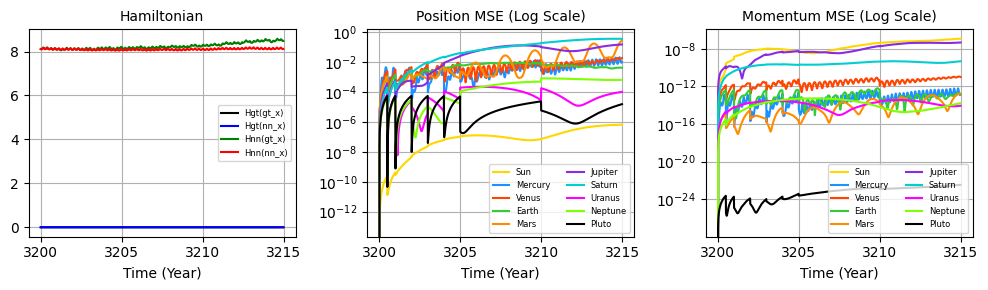

i: 8, interval=[0 : 2000]
x0: (1, 60)
part1-scipy_eval_[0 : 2000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


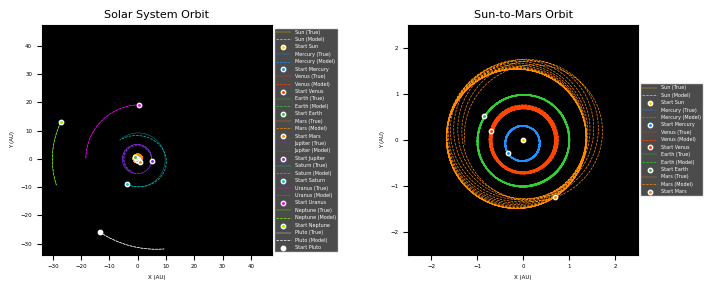

part1-scipy_metric_[0 : 2000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


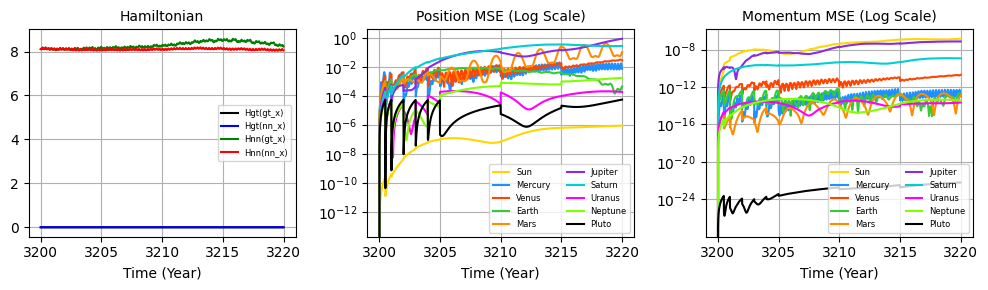

i: 9, interval=[0 : 3000]
x0: (1, 60)
part1-scipy_eval_[0 : 3000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


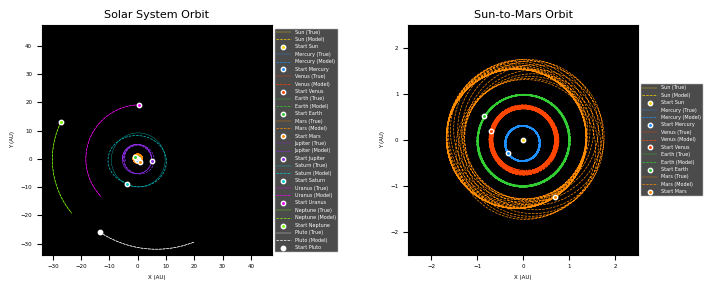

part1-scipy_metric_[0 : 3000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


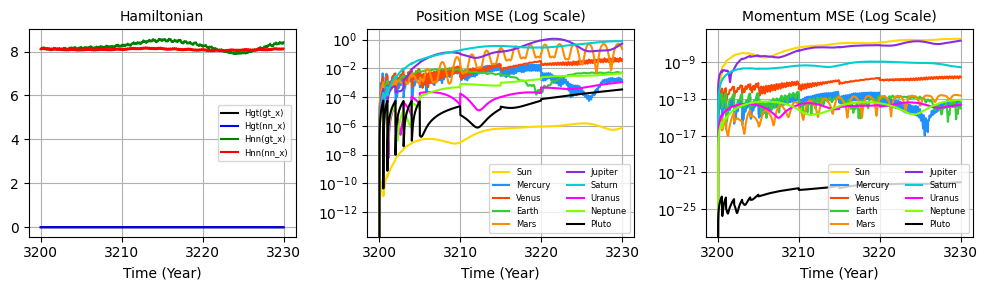

i: 10, interval=[0 : 4000]
x0: (1, 60)
part1-scipy_eval_[0 : 4000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


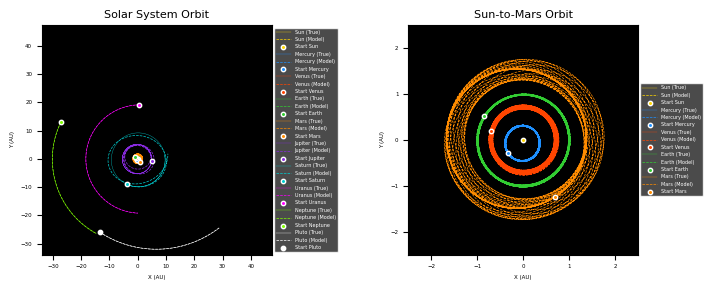

part1-scipy_metric_[0 : 4000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


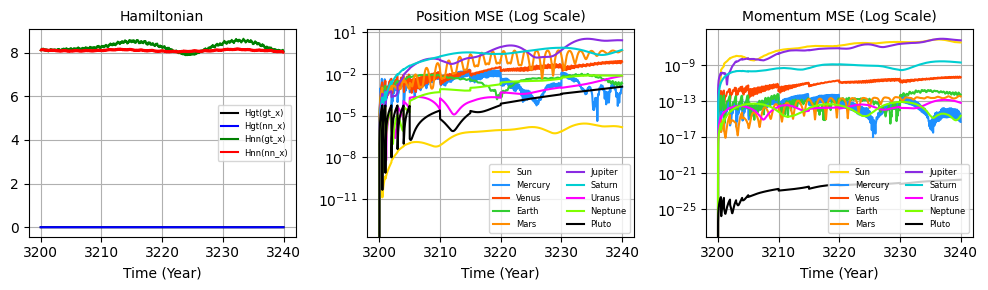

i: 11, interval=[0 : 5000]
x0: (1, 60)
part1-scipy_eval_[0 : 5000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


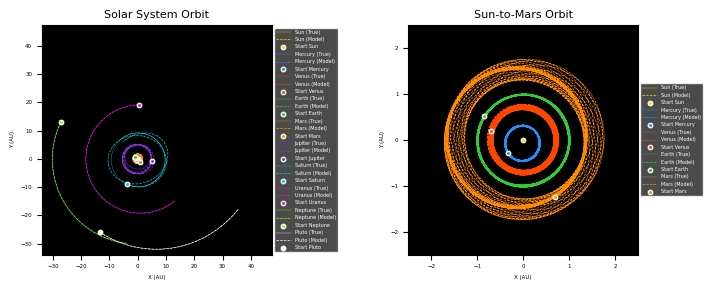

part1-scipy_metric_[0 : 5000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


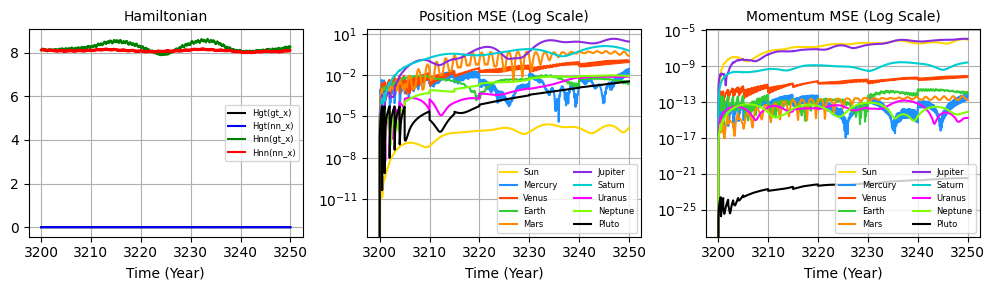

i: 12, interval=[0 : 10000]
x0: (1, 60)
part1-scipy_eval_[0 : 10000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


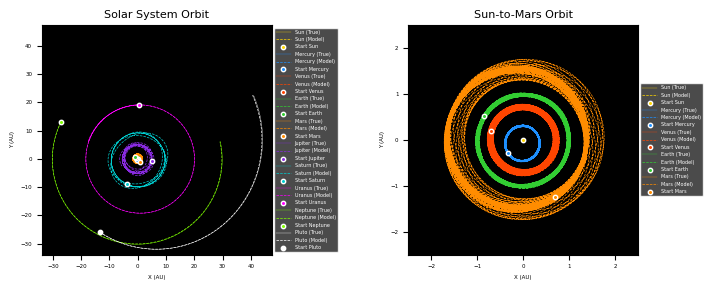

part1-scipy_metric_[0 : 10000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


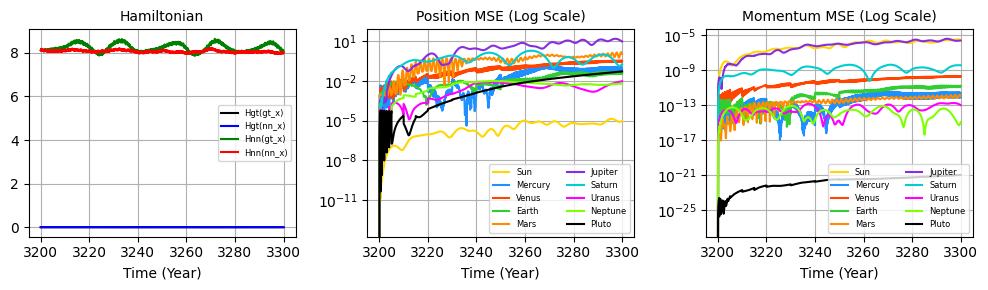

i: 13, interval=[0 : 15000]
x0: (1, 60)
part1-scipy_eval_[0 : 15000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


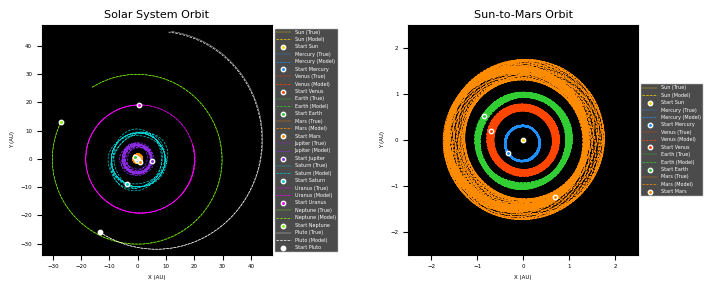

part1-scipy_metric_[0 : 15000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


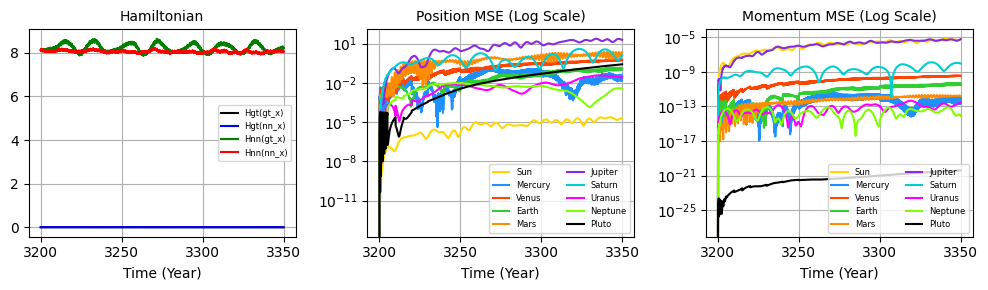

i: 14, interval=[0 : 20000]
x0: (1, 60)
part1-scipy_eval_[0 : 20000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


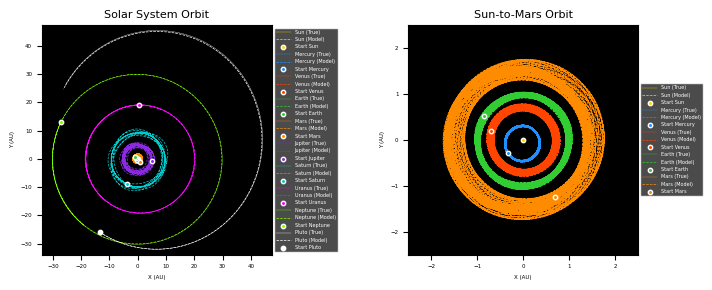

part1-scipy_metric_[0 : 20000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


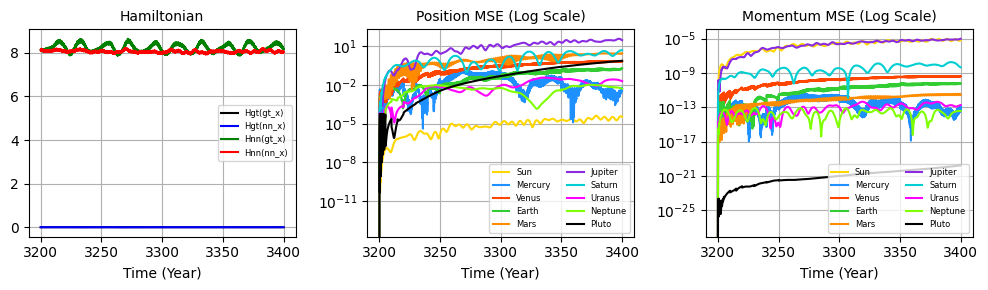

i: 15, interval=[0 : 25000]
x0: (1, 60)
part1-scipy_eval_[0 : 25000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


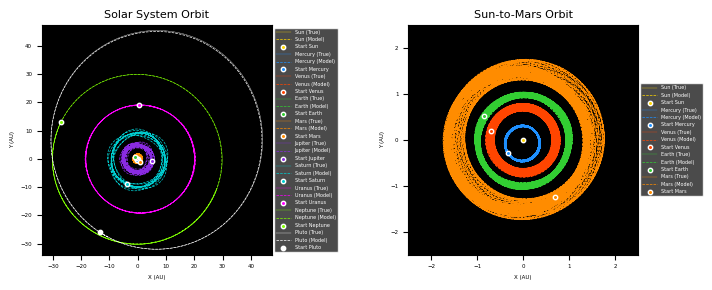

part1-scipy_metric_[0 : 25000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


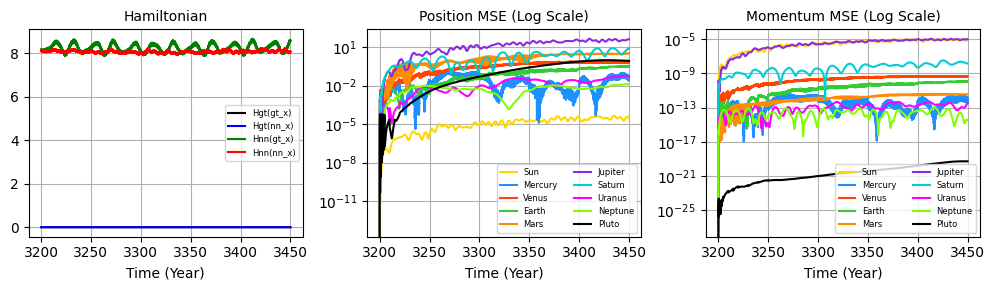

i: 16, interval=[0 : 30000]
x0: (1, 60)
part1-scipy_eval_[0 : 30000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


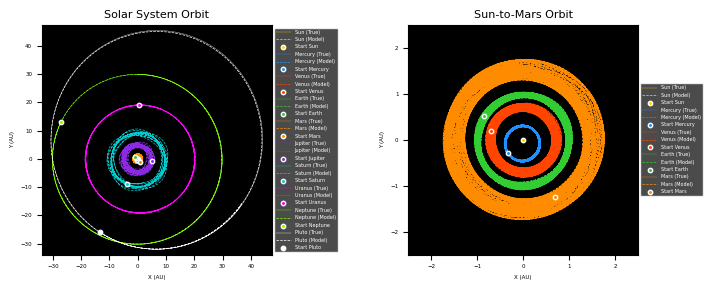

part1-scipy_metric_[0 : 30000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


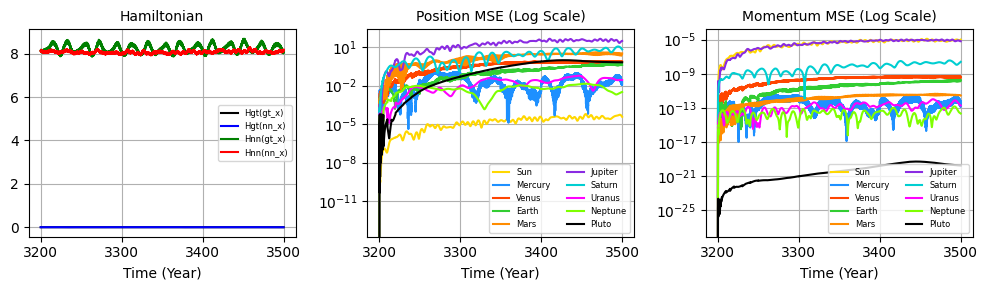

i: 17, interval=[0 : 35000]
x0: (1, 60)
part1-scipy_eval_[0 : 35000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


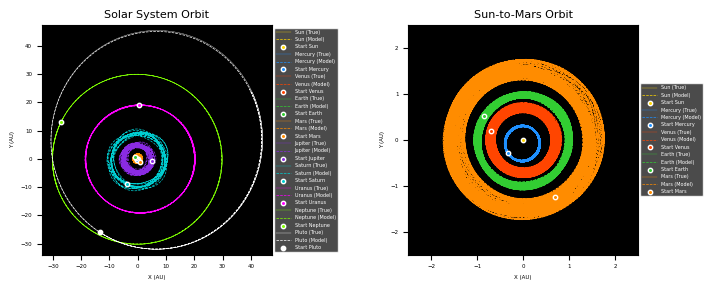

part1-scipy_metric_[0 : 35000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


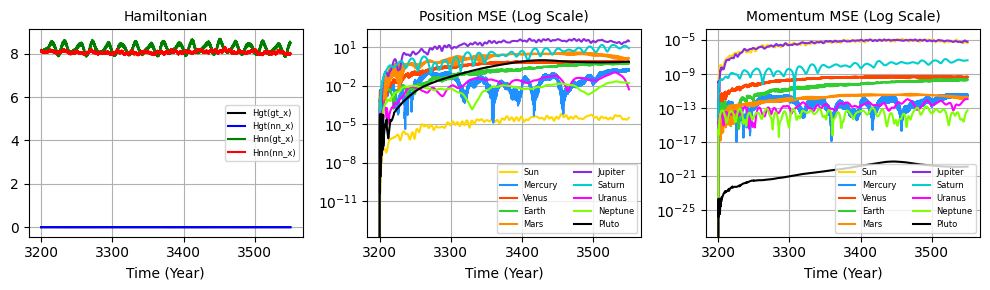

i: 18, interval=[0 : 40000]
x0: (1, 60)
part1-scipy_eval_[0 : 40000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


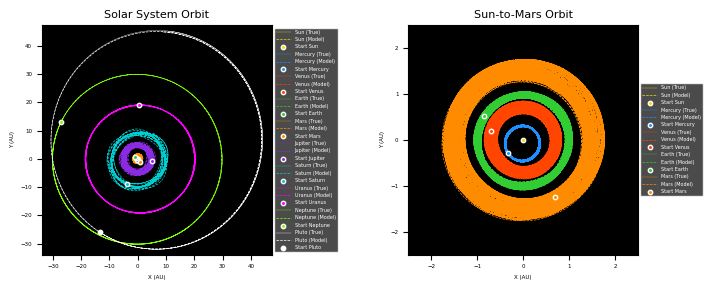

part1-scipy_metric_[0 : 40000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


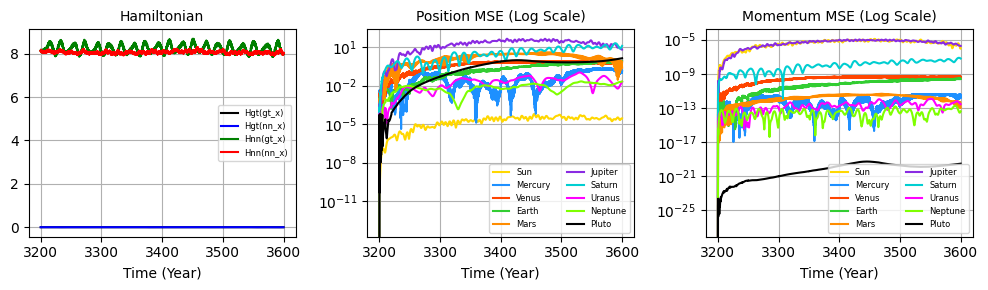

In [15]:
start_idx = 320000 # 40000 * 0.8
dt = 0.01 # 1 year = 100 steps

# upto 50 Years
eval_steps = [50, 100, 200, 300, 400, 500, 1000, 1500, 2000, 
              3000, 4000, 5000] 

if extend_time_window_upto_100Y:
   eval_steps += [10000]
if extend_time_window_upto_200Y:
   eval_steps += [15000, 20000]
if extend_time_window_upto_300Y:
   eval_steps += [25000, 30000]
if extend_time_window_upto_400Y:
   eval_steps += [35000, 40000]

gt_q, gt_p = ground_truth_orbits(q_path, p_path, start_idx, eval_steps[-1])

if len(eval_steps) > 0:
    FIG_PREFIX = f"part1-{PREFIX}"
       
    eval_on_test_set(model, device, 
                 q_max, p_max, dq_max, dp_max, dt,
                 eval_steps, gt_q, gt_p, start_idx, 
                 FIG_PREFIX, weight_filename, EVAL_FIG_DIR,
                 plt_scale_pars=plt_pars, 
                 qp_cat=False, 
                 img_save=IMG_SAVE)

i: 0, interval=[0 : 10000]
x0: (1, 60)
part2-scipy_eval_[0 : 10000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


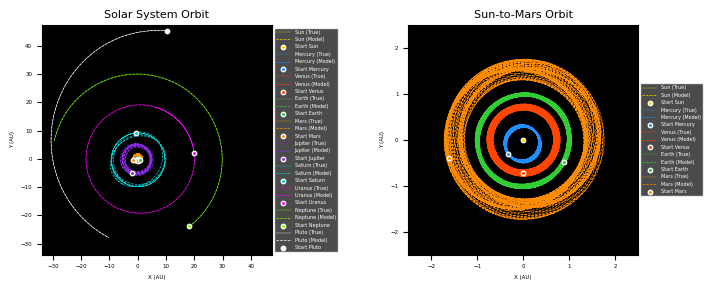

part2-scipy_metric_[0 : 10000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


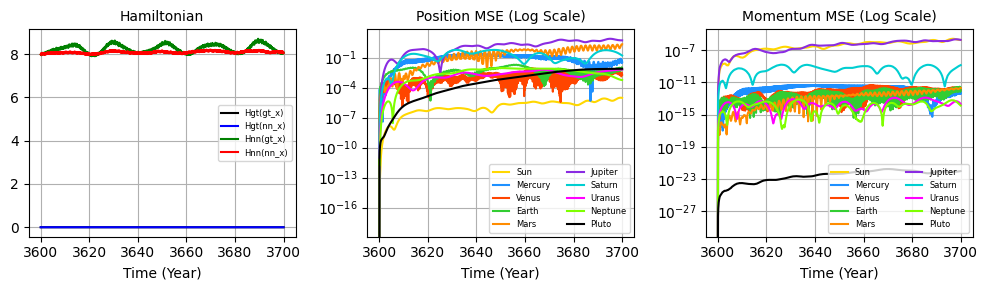

i: 1, interval=[0 : 20000]
x0: (1, 60)
part2-scipy_eval_[0 : 20000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


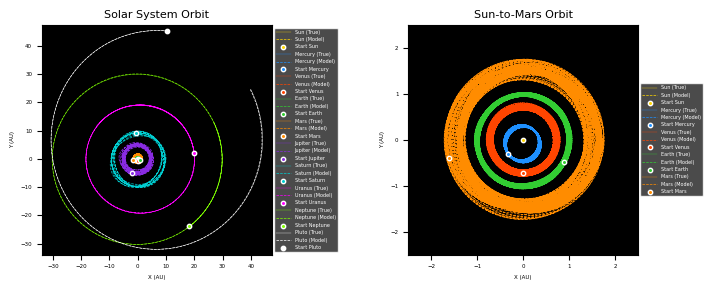

part2-scipy_metric_[0 : 20000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


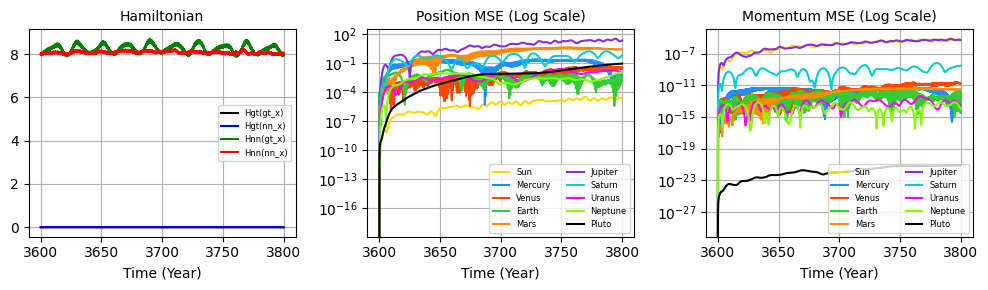

i: 2, interval=[0 : 30000]
x0: (1, 60)
part2-scipy_eval_[0 : 30000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


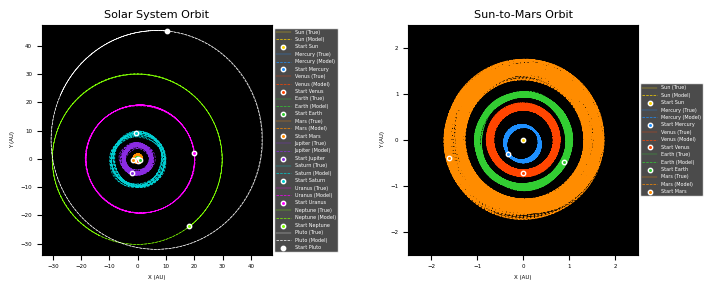

part2-scipy_metric_[0 : 30000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


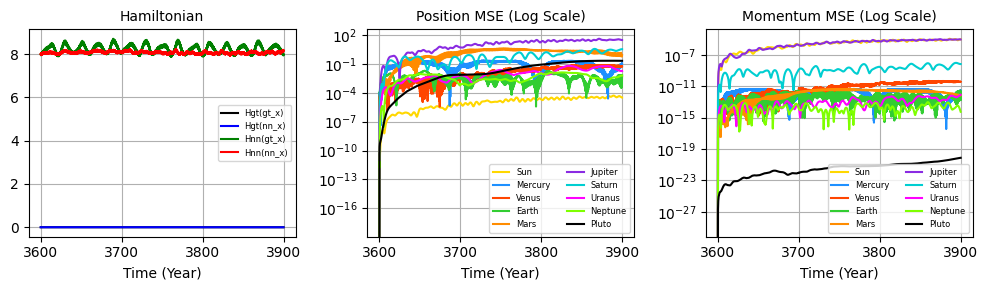

i: 3, interval=[0 : 40000]
x0: (1, 60)
part2-scipy_eval_[0 : 40000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


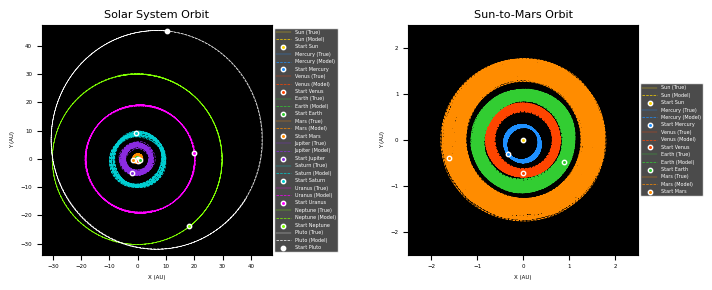

part2-scipy_metric_[0 : 40000]_opt-att-blk-p-hnn(4)(7)-bs200_ep_36_of_60_lr_1e-04_pat_3.webp


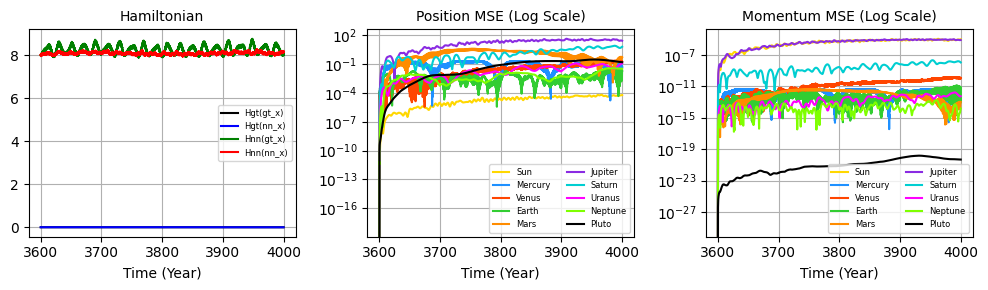

In [16]:
start_idx = 360000   # 400000 * 0.8 + 40000 = 320000 + 40000 = 360000
eval_steps = []

if extend_time_window_upto_100Y:
    eval_steps += [10000]
if extend_time_window_upto_200Y:
    eval_steps += [20000]
if extend_time_window_upto_300Y:
    eval_steps += [30000]
if extend_time_window_upto_400Y:
    eval_steps += [40000] 

dt = 0.01 # 1 year = 100 steps

if len(eval_steps) > 0:
    FIG_PREFIX = f"part2-{PREFIX}"

    gt_q, gt_p = ground_truth_orbits(q_path, p_path, start_idx, eval_steps[-1])

    eval_on_test_set(model, device, 
                 q_max, p_max, dq_max, dp_max, dt,
                 eval_steps, gt_q, gt_p, start_idx, 
                 FIG_PREFIX, weight_filename, EVAL_FIG_DIR,
                 plt_scale_pars=plt_pars, 
                 qp_cat=False, 
                 img_save=IMG_SAVE)